In [1]:
import sympy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
x = sp.Symbol('x')
y = sp.Symbol('y')
f = x**2 - x**3 + 5 + y**4 + x**2*y**2
sp.diff(sp.diff(f, x), y)
# f.subs({x: 1, y:2})
type(f)

sympy.core.add.Add

In [3]:
x_1, x_2, x_3 = sp.Symbol('x_1'), sp.Symbol('x_2'), sp.Symbol('x_3')
X = [x_1, x_2, x_3]
f = 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1
l = 0.1
e = 0.0001 
x0 = np.array([0, 0, 0])
res = []
while True:
    x_rand_i = np.random.randint(0, len(X)+1)
    x1 = x0 - l*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
    res.append([x0, f.subs(dict(zip(X, x0)))])
    if abs(sum(x1 - x0)) < e:
        break
    x0 = x1
res

[[array([0, 0, 0]), 1],
 [array([0, 0, 0.200000000000000], dtype=object), 0.800000000000000],
 [array([0.0800000000000000, 0, 0.200000000000000], dtype=object),
  0.768000000000000],
 [array([0.0800000000000000, 0.0160000000000000, 0.232000000000000],
        dtype=object),
  0.760832000000000],
 [array([0.0960000000000000, 0.0256000000000000, 0.232000000000000],
        dtype=object),
  0.758507520000000],
 [array([0.0979200000000000, 0.0345600000000000, 0.238400000000000],
        dtype=object),
  0.757558476800000],
 [array([0.102272000000000, 0.0403200000000000, 0.239168000000000],
        dtype=object),
  0.757131902976000],
 [array([0.103731200000000, 0.0446464000000000, 0.240908800000000],
        dtype=object),
  0.756933575966720],
 [array([0.105292800000000, 0.0475340800000000, 0.241492480000000],
        dtype=object),
  0.756840305315021],
 [array([0.106103808000000, 0.0495790080000000, 0.242117120000000],
        dtype=object),
  0.756796268667208],
 [array([0.106762649600

In [4]:
np.random.randint(0,2)

1

In [5]:
def vanil_gradient_descent(
    variable: list,
    f,
    x0: np.ndarray = np.array([]),
    /,
    step: float=0.1,
    error: float=0.01,
    itteration: int=100
) -> str:
    '''Ванильный градиентный спуск с заданным шагом h'''
    if len(x0) != len(variable):
        return 'Размерность начальной точки не корректна'
    X = list(map(sp.Symbol, variable))
    x0 = np.array(x0) 
    res = []
    i = 0
    while True:
        x1 = x0 - step*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
        if abs(sum(x1 - x0)) < error:
            res.append([x0, f.subs(dict(zip(X, x0)))])
            return f'Приблеженные значения точки минимума: {res[0][0]} со значением {res[0][1]}, с точностью до погрешности {error}'
        x0 = x1
        i += 1
        if i > itteration:
            return f'Число иттераций превысило {itteration}'

In [6]:
vanil_gradient_descent(['x', 'y'], (x-y+5)**2 + (y-2)**3 - x*y + 34, [0, 0], step=0.01, itteration=1000, error=0.3)

'Приблеженные значения точки минимума: [0 0] со значением 51, с точностью до погрешности 0.3'

In [7]:
x_1, x_2, x_3 = sp.Symbol('x_1'), sp.Symbol('x_2'), sp.Symbol('x_3')
X = [x_1, x_2, x_3]
f = 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1
l = 0.1
e = 0.1 
x0 = np.array([0, 0, 0])
res = []
H = [[sp.diff(sp.diff(f, X[i]), X[j]).subs(dict(zip(X, x0))) for i in range(len(X))] for j in range(len(X))]
while True:
    S = np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
    t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(X, x0))))
    x1 = x0 - t*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
    res.append([x0, f.subs(dict(zip(X, x0)))])
    if abs(sum(x1 - x0)) < e:
        break
    x0 = x1
res

[[array([0, 0, 0]), 1],
 [array([0, 0, 0.200000000000000], dtype=object), 0.800000000000000]]

In [8]:
def gradient_descent(
    variable: list,
    f,
    x0: np.ndarray = np.array([]),
    /,
    error: float=0.001,
    itteration: int=1000,
    describe: bool=False,
    nround: int=3,
    convergence: bool=False
) -> str:
    '''Наискорейший градиентный спуск с вычесленным h'''
    if len(x0) != len(variable):
        return 'Размерность начальной точки не корректна'
    X = list(map(sp.Symbol, variable))
    x0 = np.array(x0) 
    res = []
    i = 0
    H = [[sp.diff(sp.diff(f, X[i]), X[j]).subs(dict(zip(X, x0))) for i in range(len(X))] for j in range(len(X))]
    while True:
        S = np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
        t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(X, x0))))
        x1 = x0 - t*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
        res.append([[round(_, nround) for _ in x0], f.subs(dict(zip(X, x0)))])
        if describe:
            print(f'Иттерация №{i} с шагом {t} в точке приближения {dict(zip(X, res[-1][0]))} со значением {f.subs(dict(zip(X, x0)))} и погрешностью {abs(sum(x1 - x0))}')
        if abs(sum(x1 - x0)) < error:
            if convergence:
                sns.pointplot(x=range(i+1), y=[float(_[1]) for _ in res])
                plt.grid()
            return f'Приблеженные значения точки минимума: {dict(zip(X, res[-1][0]))} со значением {res[-1][1]}, с точностью {error}'
        x0 = x1
        i += 1
        if i > itteration:
            return f'Число иттераций превысило {itteration}'

Иттерация №0 с шагом 0.1 в точке приближения {x_1: np.int64(0), x_2: np.int64(0), x_3: np.int64(0)} со значением 1 и погрешностью 0.200000000000000
Иттерация №1 с шагом 0.10000000000000002 в точке приближения {x_1: 0, x_2: 0, x_3: 0.2000000} со значением 0.800000000000000 и погрешностью 0.0800000000000000
Иттерация №2 с шагом 0.11363636363636358 в точке приближения {x_1: 0.0800000, x_2: 0, x_3: 0.2000000} со значением 0.768000000000000 и погрешностью 0.0545454545454545
Иттерация №3 с шагом 0.1120233787920956 в точке приближения {x_1: 0.0800000, x_2: 0.0181818, x_3: 0.2363636} со значением 0.760727272727273 и погрешностью 0.0252561799458542
Иттерация №4 с шагом 0.11819772058200705 в точке приближения {x_1: 0.1003679, x_2: 0.0279584, x_3: 0.2314753} со значением 0.758342378315963 и погрешностью 0.0181740322315027
Иттерация №5 с шагом 0.11273491526340099 в точке приближения {x_1: 0.0977840, x_2: 0.0384664, x_3: 0.2417252} со значением 0.757402616922668 и погрешностью 0.00919688646499075
И

Иттерация №8 с шагом 0.11830341197137738 в точке приближения {x_1: 0.1069440, x_2: 0.0495930, x_3: 0.2414373} со значением 0.756800846995669 и погрешностью 0.00288830018157288
Иттерация №9 с шагом 0.11274718204246381 в точке приближения {x_1: 0.1064110, x_2: 0.0514286, x_3: 0.2430229} со значением 0.756774779053128 и погрешностью 0.00150642122439918
Иттерация №10 с шагом 0.11830343918662778 в точке приближения {x_1: 0.1076330, x_2: 0.0522300, x_3: 0.2425060} со значением 0.756764123544527 и погрешностью 0.00117972837531746
Иттерация №11 с шагом 0.11274718518045675 в точке приближения {x_1: 0.1074146, x_2: 0.0529807, x_3: 0.2431534} со значением 0.756759768002700 и погрешностью 0.000615585657194766


'Приблеженные значения точки минимума: {x_1: 0.1074146, x_2: 0.0529807, x_3: 0.2431534} со значением 0.756759768002700, с точностью 0.001'

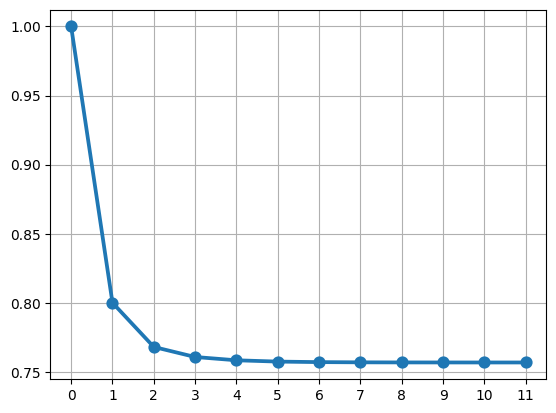

In [9]:
gradient_descent(['x_1', 'x_2', 'x_3'], 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1, [0, 0, 0], error=0.001, describe=True, nround=7, convergence=True)

In [10]:
w1 = sp.Symbol('w1')
w2 = sp.Symbol('w2')
W = np.array([w1, w2])
X = np.array([[1.2, 4.5], [2.4, 6.7], [5.4, 8.9]])
sum((X@W)).subs({w1: 1, w2:2})

49.2000000000000

In [11]:
df = pd.read_csv('D:/ProjectPython/Анализ даных/Пакеты прикладных программ/FOOD-DATA-GROUP1 (1).csv').loc[:, 'Caloric Value':'Monounsaturated Fats']
df

,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats
0,51,5.0,2.900,1.300
1,215,19.4,10.900,4.900
2,49,3.6,2.300,0.900
3,30,2.0,1.300,0.500
4,30,2.3,1.400,0.600
...,...,...,...,...
546,159,5.9,1.300,2.800
547,50,3.4,0.500,1.600
548,33,0.3,0.049,0.006
549,147,1.3,0.300,0.400


In [34]:
X = np.array(df.loc[:, 'Caloric Value':'Saturated Fats'])
Y = np.array(df['Monounsaturated Fats'])
X.shape

(551, 3)

In [13]:
W0 = sp.Symbol('w0')
W = sp.symbols(f'w1:{X.shape[1]+1}')
W

(w1, w2, w3)

In [27]:
list(map(str, np.hstack(['w0', W])))

['w0', 'w1', 'w2', 'w3']

In [14]:
sum((W0+X@W-Y)**2)

(w0 + 49.0*w1)**2 + (w0 + 64.0*w1)**2 + (w0 + 159.0*w1)**2 + (w0 + 167.0*w1)**2 + (w0 + 17.0*w1 + 0.2*w2)**2 + (w0 + 27.0*w1 + 0.6*w2)**2 + (w0 + 27.0*w1 + 1.0*w2)**2 + (w0 + 47.0*w1 + 2.6*w2)**2 + (w0 + 54.0*w1 + 2.4*w2)**2 + (w0 + 68.0*w1 + 1.8*w2)**2 + (w0 + 106.0*w1 + 0.8*w2)**2 + (w0 + 168.0*w1 + 1.2*w2)**2 + (w0 + 363.0*w1 + 25.4*w2)**2 + (w0 + 388.0*w1 + 12.0*w2)**2 + (w0 + 546.0*w1 + 19.6*w2)**2 + (w0 + 8.0*w1 + 0.2*w2 - 0.087)**2 + (w0 + 48.0*w1 + 0.01*w2 + 0.042*w3)**2 + (w0 + 75.0*w1 + 6.0*w2 + 4.0*w3)**2 + (w0 + 100.0*w1 + 5.5*w2 + 5.3*w3)**2 + (w0 + 110.0*w1 + 0.3*w2 + 0.02*w3)**2 + (w0 + 320.0*w1 + 16.0*w2 - 48.0)**2 + (w0 + 3.0*w1 + 0.048*w2 + 0.01*w3 - 0.043)**2 + (w0 + 3.0*w1 + 0.1*w2 + 0.08*w3 - 0.035)**2 + (w0 + 4.0*w1 + 0.023*w2 + 0.061*w3 - 0.075)**2 + (w0 + 7.0*w1 + 0.092*w2 + 0.023*w3 - 0.003)**2 + (w0 + 8.0*w1 + 0.2*w2 + 0.073*w3 - 0.004)**2 + (w0 + 8.0*w1 + 0.3*w2 + 0.2*w3 - 0.1)**2 + (w0 + 8.0*w1 + 0.4*w2 + 0.001*w3 - 0.2)**2 + (w0 + 10.0*w1 + 0.091*w2 + 0.089

In [15]:
sp.diff(sum((W0+X@W-Y)**2), w2)

11865.16*w0 + 5315372.066*w1 + 300843.932072*w2 + 103419.275286*w3 - 107971.626464

In [16]:
[sp.diff(sum((W0+X@W-Y)**2), list(sp.symbols(f'w0:{X.shape[1]+1}'))[i]).subs(dict(zip(list(sp.symbols(f'w0:{X.shape[1]+1}')), [0,0,0,0]))) for i in range(len(list(sp.symbols(f'w0:{X.shape[1]+1}'))))]

[-4409.72400000000, -1901941.19600000, -107971.626464000, -38250.1393680001]

In [35]:
list(sp.symbols(f'w0:{X.shape[1]+1}'))

[w0, w1, w2, w3]

In [20]:
np.random.randint(-2,2, 5)

array([-2, -2, -2, -2, -1], dtype=int32)

In [39]:
gradient_descent(['w0', 'w1', 'w2', 'w3'], sum((W0+X@W-Y)**2), [0,0,0,0], describe=True)

Иттерация №0 с шагом 9.430231004043318e-09 в точке приближения {w0: np.int64(0), w1: np.int64(0), w2: np.int64(0), w3: np.int64(0)} со значением 25706.9842700000 и погрешностью 0.0193562345799854
Иттерация №1 с шагом 2.0744226279609392e-05 в точке приближения {w0: 0.0, w1: 0.018, w2: 0.001, w3: 0.0} со значением 8588.65981820324 и погрешностью 0.367539749576982
Иттерация №2 с шагом 9.430285444851621e-09 в точке приближения {w0: -0.006, w1: 0.001, w2: 0.256, w3: 0.136} со значением 6568.45694851712 и погрешностью 0.00228323231951952
Иттерация №3 с шагом 2.251384233819257e-05 в точке приближения {w0: -0.006, w1: 0.003, w2: 0.256, w3: 0.136} со значением 6330.04186472595 и погрешностью 0.0444456514259938
Иттерация №4 с шагом 9.43217412613594e-09 в точке приближения {w0: -0.004, w1: 0.001, w2: 0.294, w3: 0.143} со значением 6296.21928910282 и погрешностью 0.000321673070233057


'Приблеженные значения точки минимума: {w0: -0.004, w1: 0.001, w2: 0.294, w3: 0.143} со значением 6296.21928910282, с точностью 0.001'

In [37]:
def gradient_descent_df(X, Y, describe=False):
    X = np.array(X)
    Y = np.array(Y)
    W0 = sp.Symbol('w0')
    W = sp.symbols(f'w1:{X.shape[1]+1}')
    loss = sum((W0+X@W-Y)**2)
    variables = list(map(str, np.hstack(['w0', W])))
    x0 = np.zeros(X.shape[1]+1, dtype=int)
    
    return gradient_descent(variables, loss, x0, describe=describe)

In [40]:
gradient_descent_df(df.loc[:, 'Caloric Value':'Saturated Fats'], df['Monounsaturated Fats'])

KeyboardInterrupt: 